### Project Overview

The goal of this project is to:

- Clean and preprocess the data by handling missing values, duplicate records, and outliers.
- Perform an exploratory data analysis (EDA) to summarize key statistics, revenue distribution, and customer behavior.
- Apply clustering techniques (KMeans and Hierarchical Clustering) to segment customers based on their purchasing behavior.
- Evaluate the clustering results using silhouette scores and visualization.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, silhouette_score
import plotly.express as px
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering

In [2]:
# Load the data
file_path = 'Online Retail.xlsx'
df = pd.read_excel(file_path)

# Basic Data Exploration
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Information:")
print(df.info())
print("\nDescriptive Statistics for Numerical Columns:")
print(df.describe())

First 5 rows of the dataset:
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null C

In [3]:
# Data Cleaning
df = df.dropna(subset=['CustomerID'])
df['Description'] = df['Description'].fillna('Unknown')
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].drop_duplicates()

# Convert CustomerID to integer and create TotalPrice feature
df['CustomerID'] = df['CustomerID'].astype(int)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Display cleaned data summary
print("Cleaned Dataset Information:")
print(df.info())
print("\nDescriptive Statistics After Cleaning:")
print(df.describe())


Cleaned Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int32         
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(4)
memory usage: 28.5+ MB
None

Descriptive Statistics After Cleaning:
            Quantity                    InvoiceDate      UnitPrice  \
count  392692.000000                         392692  392692.000000   
mean       13.119702  2011-07-10 19:13:

In [4]:
# Outlier Analysis and Handling
# Define thresholds for outliers (using 99th percentile for this example)
q_upper_limit = df['Quantity'].quantile(0.99)
up_upper_limit = df['UnitPrice'].quantile(0.99)
tp_upper_limit = df['TotalPrice'].quantile(0.99)

# Replace outliers with the capped value (99th percentile value)
df['Quantity'] = np.where(df['Quantity'] > q_upper_limit, q_upper_limit, df['Quantity'])
df['UnitPrice'] = np.where(df['UnitPrice'] > up_upper_limit, up_upper_limit, df['UnitPrice'])
df['TotalPrice'] = np.where(df['TotalPrice'] > tp_upper_limit, tp_upper_limit, df['TotalPrice'])

# Check the effects of capping outliers
print("\nDescriptive Statistics After Capping Outliers:")
print(df.describe())


Descriptive Statistics After Capping Outliers:
            Quantity                    InvoiceDate      UnitPrice  \
count  392692.000000                         392692  392692.000000   
mean       11.022402  2011-07-10 19:13:07.771892480       2.833364   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 12:02:00       1.950000   
75%        12.000000            2011-10-20 12:53:00       3.750000   
max       120.000000            2011-12-09 12:50:00      14.950000   
std        18.158425                            NaN       2.792072   

          CustomerID     TotalPrice  
count  392692.000000  392692.000000  
mean    15287.843865      19.151577  
min     12346.000000       0.001000  
25%     13955.000000       4.950000  
50%     15150.000000      12.450000  
75%     16791.000000      19.800000  
max     18287.000000     203.520000  
std      1713.539

In [5]:
# Feature Engineering
# Extracting additional features from InvoiceDate
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

In [6]:

# RFM Analysis
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',  # Frequency (Number of invoices)
    'TotalPrice': 'sum'  # Monetary Value
}).reset_index().rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'MonetaryValue'
})

print("\nRFM Analysis Sample:")
print(rfm.head())



RFM Analysis Sample:
   CustomerID  Recency  Frequency  MonetaryValue
0       12346      326          1         203.52
1       12347        2          7        4263.92
2       12348       75          4        1760.76
3       12349       19          1        1661.07
4       12350      310          1         334.40


In [7]:
# Exploratory Data Analysis (EDA)
total_revenue = df['TotalPrice'].sum()
average_revenue = df['TotalPrice'].mean()
order_value_df = df.groupby('InvoiceNo')['TotalPrice'].sum()  # Summing TotalPrice per invoice
average_order_value = order_value_df.mean()
unique_customers = df['CustomerID'].nunique()
customer_order_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

# Display Summary Statistics
print("Summary Statistics:")
print(f"Total Revenue: {total_revenue}")
print(f"Average Revenue: {average_revenue}")
print(f"Average Order Value: {average_order_value}")
print(f"Number of Unique Customers: {unique_customers}")
print(f"Average Order Frequency per Customer: {customer_order_frequency.mean()}")

Summary Statistics:
Total Revenue: 7520671.073999999
Average Revenue: 19.15157699673026
Average Order Value: 405.82080045327007
Number of Unique Customers: 4338
Average Order Frequency per Customer: 4.272014753342554


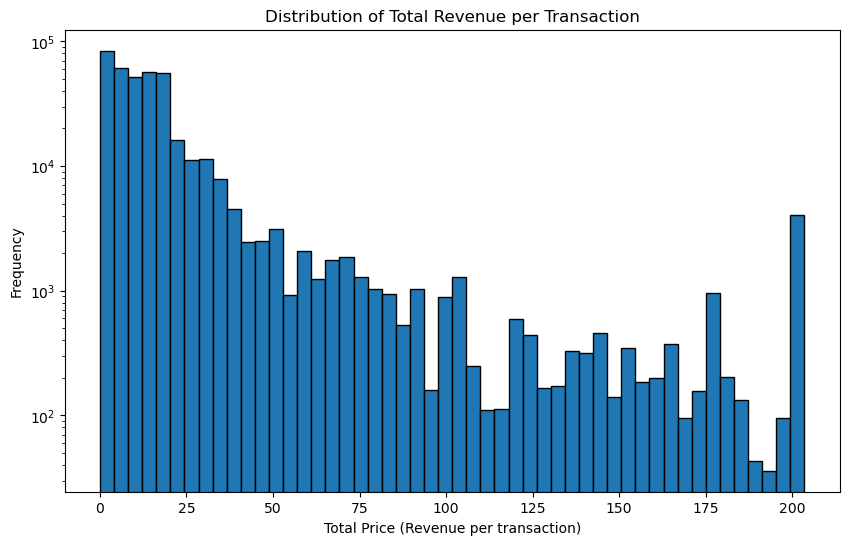

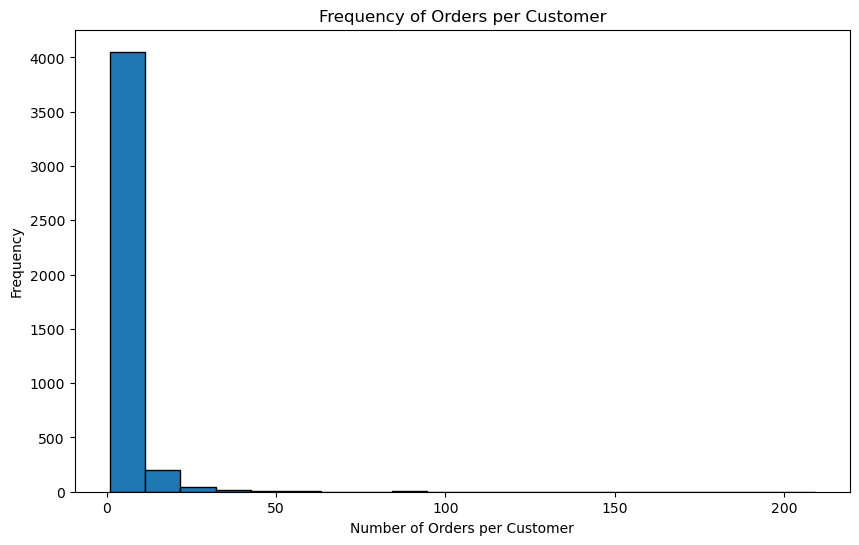

In [8]:
# Visualizations
plt.figure(figsize=(10, 6))
plt.hist(df['TotalPrice'], bins=50, edgecolor='k')
plt.xlabel('Total Price (Revenue per transaction)')
plt.ylabel('Frequency')
plt.title('Distribution of Total Revenue per Transaction')
plt.yscale('log')  # Log scale to handle skewness
plt.show()

# Visualizations for Frequency of Orders and Recency
plt.figure(figsize=(10, 6))
plt.hist(customer_order_frequency, bins=20, edgecolor='k')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Frequency')
plt.title('Frequency of Orders per Customer')
plt.show()


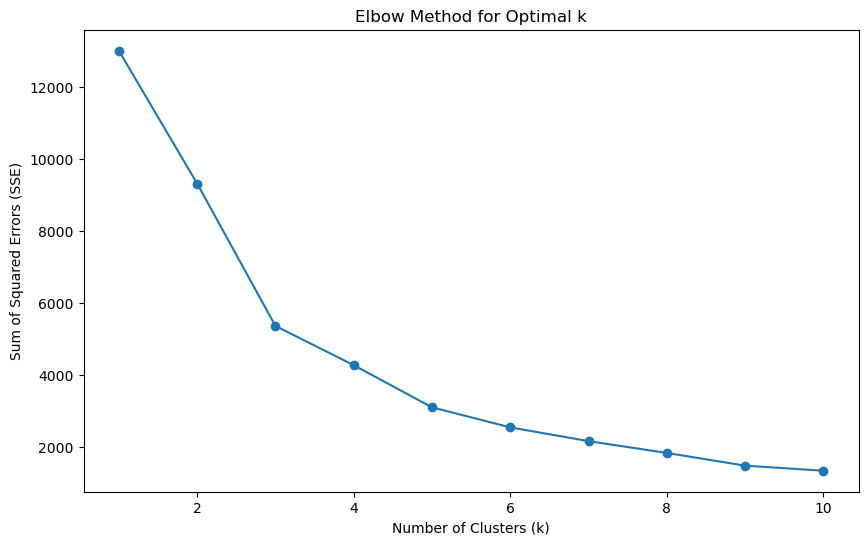

In [9]:
# Customer Segmentation using KMeans and Hierarchical Clustering
scaler = StandardScaler()
rfm_normalized = scaler.fit_transform(rfm[['Recency', 'Frequency', 'MonetaryValue']])

# KMeans Clustering
sse = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_normalized)
    sse.append(kmeans.inertia_)

# Elbow Method for Optimal k
plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method for Optimal k')
plt.show()


In [10]:
# Choosing k and fitting KMeans
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
rfm['KMeans_Cluster'] = kmeans.fit_predict(rfm_normalized)

# Silhouette Score
silhouette_avg = silhouette_score(rfm_normalized, rfm['KMeans_Cluster'])
print(f"Silhouette Score for k={optimal_k}: {silhouette_avg}")


Silhouette Score for k=4: 0.6024376129972974


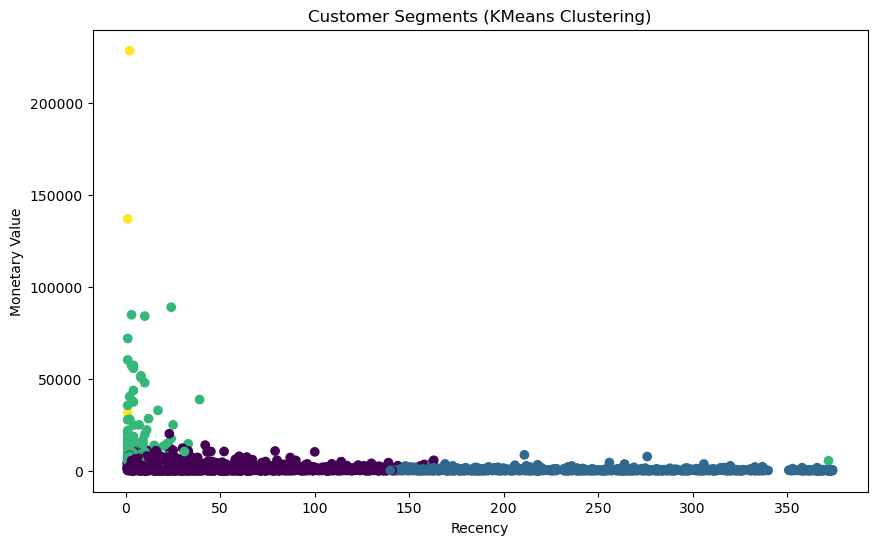

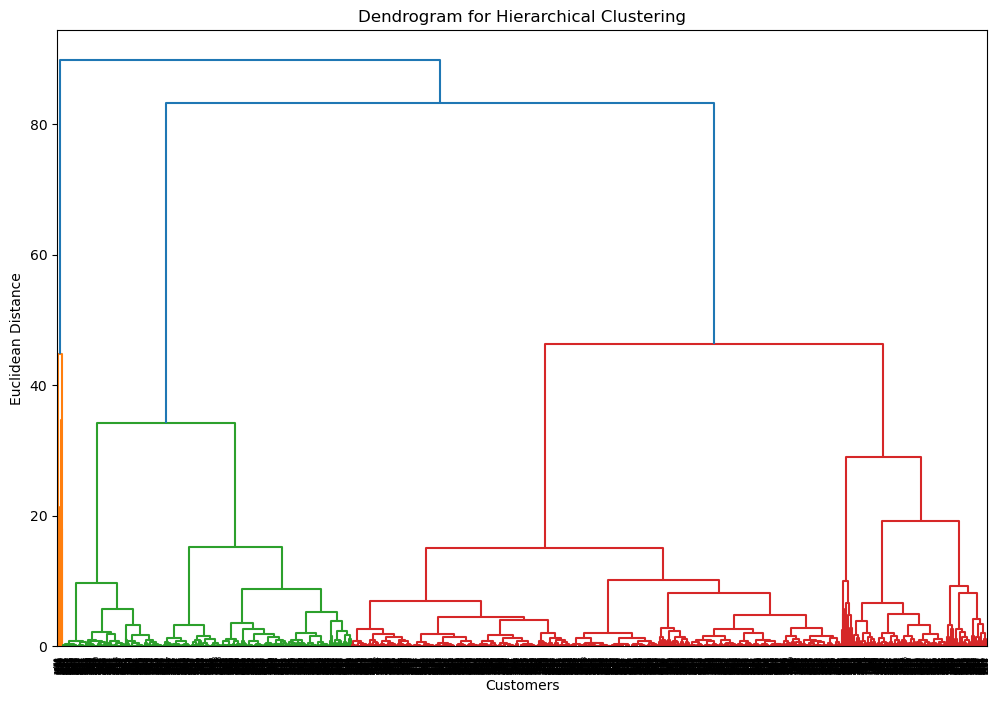

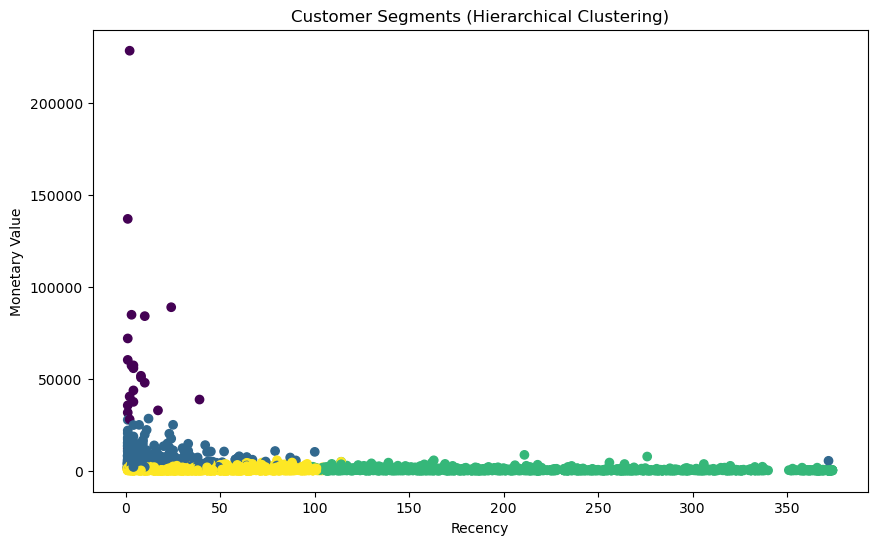

In [11]:
# Visualize KMeans Clusters
plt.figure(figsize=(10, 6))
plt.scatter(rfm['Recency'], rfm['MonetaryValue'], c=rfm['KMeans_Cluster'], cmap='viridis')
plt.xlabel('Recency')
plt.ylabel('Monetary Value')
plt.title('Customer Segments (KMeans Clustering)')
plt.show()

# Hierarchical Clustering (Agglomerative)
linkage_matrix = linkage(rfm_normalized, method='ward')
plt.figure(figsize=(12, 8))
dendrogram(linkage_matrix)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

agg_cluster = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
rfm['Agg_Cluster'] = agg_cluster.fit_predict(rfm_normalized)

# Visualization of Hierarchical Clusters
plt.figure(figsize=(10, 6))
plt.scatter(rfm['Recency'], rfm['MonetaryValue'], c=rfm['Agg_Cluster'], cmap='viridis')
plt.xlabel('Recency')
plt.ylabel('Monetary Value')
plt.title('Customer Segments (Hierarchical Clustering)')
plt.show()